# Catalogue des ablations

Ce notebook montre l'effet visuel de chaque ablation (A1-A7) telle qu'elle
est reellement executee par le pipeline d'entrainement (`src/chain.py`) —
pas une reimplementation separee pour le notebook. Chaque section rejoue la
chaine canonique du protocole (§2) sur le meme oiseau et le meme sac de
crops, en n'activant qu'une ablation a la fois (ou une combinaison, en fin
de notebook), pour que les panneaux soient directement comparables — comme
la figure 2 du protocole.

Le timing detaille de chaque ablation (ce qui est lent, ce qui ne l'est pas)
n'est pas ici : voir `scripts/benchmark_ablations.py`, qui existe
specifiquement pour ca et dont ce notebook ne duplique pas le travail.


In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import yaml

from pathlib import Path

from src.chain import build_bag
from src.rng import derive_rng
from src.ablations.common import Condition
from src.ablations import a3_block_permutation, a4_directional_blur, a5_spectral_slope, a6_colour_removal
from src.ablations.combinations import all_admissible_conditions, marginal_inclusion_probabilities, K_PROBABILITIES
from src import npy_io, color

with open("../configs/paths.yaml") as f:
    paths_cfg = yaml.safe_load(f)

DATASET_DIR = Path(paths_cfg["dataset_dir"])
DATASET_A2_DIR = Path(paths_cfg["dataset_a2_dir"])

# a specimen that already has an A2 cache entry built (scripts/build_a2_cache.py
# was run once on the first few specimens while developing this project) —
# pick a different stem here if you've built the full A2 cache and want a
# more colourful bird.
STEM = "Abeillia_abeillei_1_M_Back_Vis_G199130"

# same geometry (flip + the 16 crop positions) for every condition shown
# below, so panels are directly comparable — exactly the mechanism
# evaluate.py uses for the same reason (protocole §7).
GEOMETRY_RNG_SEED = ("notebook-demo", STEM)

# which crop in the (16, 224, 224, 3) bag to display: index 8 is the first
# native-224 crop (indices 0-7 are the 128px crops, resized up and visibly
# softer — see chain.CROP_SIZES).
DISPLAY_CROP_INDEX = 8


def build(codes=(), **fixed):
    condition = Condition(active=frozenset(codes))
    rng = derive_rng("notebook-condition", STEM, condition, fixed)
    geometry_rng = derive_rng(*GEOMETRY_RNG_SEED)
    bag, meta = build_bag(
        DATASET_DIR, DATASET_A2_DIR, STEM, condition, rng, positions_rng=geometry_rng, **fixed
    )
    return bag, meta


def show(panels, suptitle=None, figsize_per_panel=2.6):
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_panel * n, figsize_per_panel + 0.6))
    if n == 1:
        axes = [axes]
    for ax, (title, crop) in zip(axes, panels):
        ax.imshow(crop)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()


## L'oiseau de demonstration, et le sac de reference

Le crop affiche est toujours le meme (`DISPLAY_CROP_INDEX = 8`, le premier
crop 224 natif) sur le meme sac — seule la condition change d'un panneau a
l'autre.


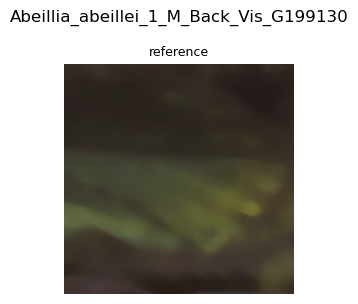

flip: True
positions (size, y, x) for the displayed crop: (224, 893, 1733)


In [2]:
reference_bag, reference_meta = build()
show([("reference", reference_bag[DISPLAY_CROP_INDEX])], suptitle=STEM)
print("flip:", reference_meta["flip"])
print("positions (size, y, x) for the displayed crop:", reference_meta["positions"][DISPLAY_CROP_INDEX])


## A1 — gris, L* conserve, et A7 — chromaticite seule, L* fixe

A1 et A7 sont les deux moities complementaires de la meme decomposition
CIELAB (protocole §3) : A1 retire la couleur et garde la clarte, A7 fait
l'inverse.


In [ ]:
a1_bag, a1_meta = build(codes=("A1",))
a7_bag, a7_meta = build(codes=("A7",))

show(
    [
        ("reference", reference_bag[DISPLAY_CROP_INDEX]),
        ("A1 (gris, L* conserve)", a1_bag[DISPLAY_CROP_INDEX]),
        ("A7 (chromaticite, L* fixe)", a7_bag[DISPLAY_CROP_INDEX]),
    ]
)
a7_detail = a7_meta["A7"]
print(
    "A7 gamut/roundtrip: mean chroma retention",
    round(a7_detail["mean_chroma_retention_ratio"], 4),
    " fraction of pixels with delta E > 1:",
    round(a7_detail["fraction_pixels_delta_E_gt_1"], 4),
)


## A2 — gris + niveau et contraste standardises

Contrairement aux autres, A2 n'est pas calculee ici : elle est lue dans le
cache hors-ligne construit par `scripts/build_a2_cache.py`. Si ce cache
n'existe pas encore pour `STEM`, la cellule ci-dessous l'indique clairement
plutot que de planter silencieusement.


In [ ]:
try:
    a2_bag, a2_meta = build(codes=("A2",))
    show([("reference", reference_bag[DISPLAY_CROP_INDEX]), ("A2 (gris standardise)", a2_bag[DISPLAY_CROP_INDEX])])
except FileNotFoundError as e:
    print(e)


## A6 — retrait d'une couleur

La categorie est tiree parmi celles presentes sur l'oiseau entier (protocole
§3) ; on affiche ici les deux plus etendues, comme la figure 2 du protocole.
`classify_delhey_rgb` reste l'operation la plus lente du projet — apres
optimisation (voir plus bas et `scripts/benchmark_ablations.py`) elle est
passee de ~12s a ~4-5s par oiseau sur cette machine, donc cette cellule
prend encore une grosse dizaine de secondes, pas une minute.


classify_delhey_rgb time: 5.10s
chromatic categories present on this specimen: ['blue', 'purple', 'red', 'yellow', 'green', 'rufous', 'light_brown', 'dark_brown']


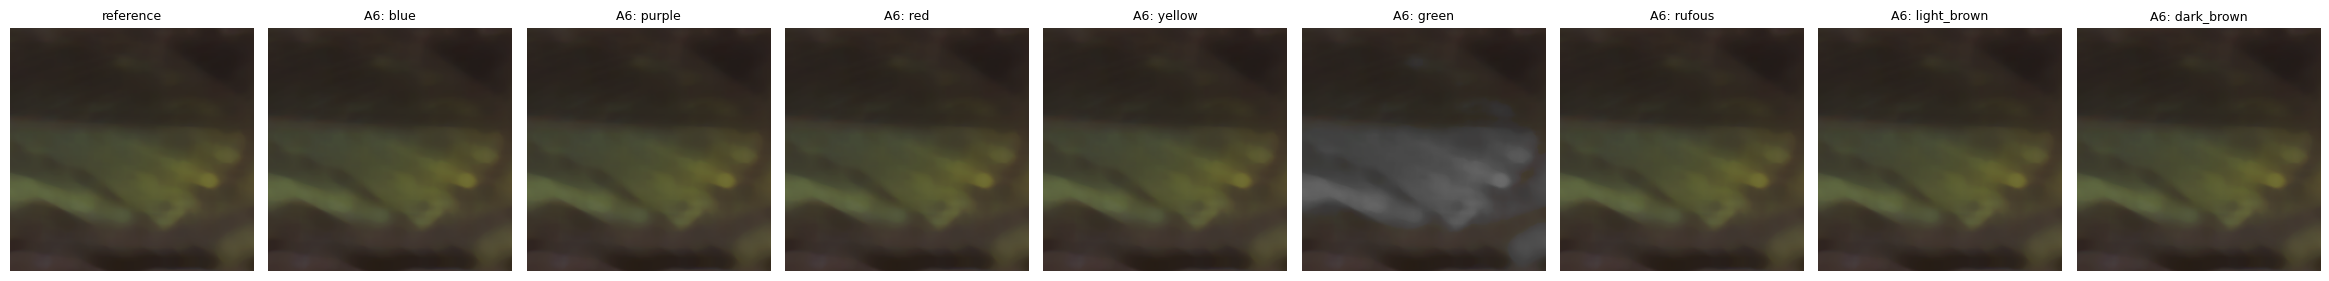

In [3]:
canvas = npy_io.read_canvas(DATASET_DIR, STEM)
mask = npy_io.foreground_mask(canvas)
present = a6_colour_removal.categories_present(canvas, mask)
print("chromatic categories present on this specimen:", present)

panels = [("reference", reference_bag[DISPLAY_CROP_INDEX])]
for category in present:
    bag, meta = build(codes=("A6",), fixed_a6_category=category)
    panels.append((f"A6: {category}", bag[DISPLAY_CROP_INDEX]))
show(panels)


### Ce que le fix A6 a change

`draw_and_apply` (utilise par `chain.py` pendant l'entrainement) classifie
l'oiseau **une seule fois** et reutilise ce resultat pour choisir la
categorie *et* la retirer — au lieu de classifier deux fois separement
(une fois pour savoir quelles couleurs sont presentes via
`categories_present`, une deuxieme fois a l'interieur de l'ablation). La
cellule ci-dessous chronometre les deux approches sur le meme oiseau.


In [4]:
import time

rng = derive_rng("notebook-a6-timing", STEM)

t0 = time.perf_counter()
present_for_timing = a6_colour_removal.categories_present(canvas, mask)
category_for_timing = present_for_timing[0]
color.ablate_delhey_colour(
    canvas.astype(np.float64) / 255.0, category=category_for_timing, foreground=mask, strength=1.0
)
t_separate = time.perf_counter() - t0

t0 = time.perf_counter()
a6_colour_removal.draw_and_apply(canvas, mask, rng)
t_fused = time.perf_counter() - t0

print(f"deux classifications separees : {t_separate:.1f}s")
print(f"une seule (draw_and_apply)    : {t_fused:.1f}s")


classify_delhey_rgb time: 4.35s
classify_delhey_rgb time: 4.24s
deux classifications separees : 11.3s
une seule (draw_and_apply)    : 6.8s


## A3 — permutation de blocs

Les quatre cotes evalues par le protocole (§7) : du plus grossier (56px) a
la permutation pixel-a-pixel (1px), qui ne conserve que l'histogramme.


In [ ]:
panels = [("reference", reference_bag[DISPLAY_CROP_INDEX])]
for h in a3_block_permutation.SIDE_CHOICES[::3]:  # a spread across the grid, not all ten
    bag, meta = build(codes=("A3",), fixed_a3_side=h)
    panels.append((f"A3: h={h}px", bag[DISPLAY_CROP_INDEX]))
show(panels)


## A4 — flou directionnel

Les quatre coins de l'espace des parametres (protocole §3/figure 2) :
theta in {0, 90} x L in {17, 101}, les deux bornes de la loi log-uniforme.


In [ ]:
panels = [("reference", reference_bag[DISPLAY_CROP_INDEX])]
for theta in (0, 90):
    for length in (17, 101):
        bag, meta = build(codes=("A4",), fixed_a4_params={"theta": theta, "length": length})
        panels.append((f"A4: theta={theta} L={length}", bag[DISPLAY_CROP_INDEX]))
show(panels, figsize_per_panel=2.3)


## A5 — pente du spectre de Fourier

Meme crop, meme cible visee (`a5_spectral_slope.TARGET_ALPHA_224` puisque
c'est un crop 224 natif) ; la metadonnee rapporte la pente mesuree avant et
apres le regrade.


In [ ]:
a5_bag, a5_meta = build(codes=("A5",))
show([("reference", reference_bag[DISPLAY_CROP_INDEX]), ("A5", a5_bag[DISPLAY_CROP_INDEX])])

a5_crop_meta = a5_meta["crops"][DISPLAY_CROP_INDEX]["A5"]
print(f"alpha before: {a5_crop_meta['alpha_before']:.2f}  ->  after: {a5_crop_meta['alpha_after']:.2f}  (target: {a5_crop_meta['target_alpha']})")


## Combinaisons

Le tirage autorise jusqu'a trois ablations a la fois (protocole §4). Trois
exemples, dont la combinaison A4+A5 que le protocole discute explicitement
(A5 corrige la pente que A4 a durcie, mais ne defait pas son anisotropie).


In [ ]:
combo_a1_a3, _ = build(codes=("A1", "A3"))
combo_a4_a5, _ = build(codes=("A4", "A5"))
combo_triple, _ = build(codes=("A1", "A3", "A4"))

show(
    [
        ("reference", reference_bag[DISPLAY_CROP_INDEX]),
        ("A1 + A3", combo_a1_a3[DISPLAY_CROP_INDEX]),
        ("A4 + A5", combo_a4_a5[DISPLAY_CROP_INDEX]),
        ("A1 + A3 + A4", combo_triple[DISPLAY_CROP_INDEX]),
    ]
)


## Verification du tirage (protocole §4)

Sanity check independant du reste du notebook : les probabilites
marginales par ablation et le nombre total de conditions admissibles
doivent reproduire exactement la table du protocole (0,140 pour les quatre
ablations CIELAB, 0,246 pour A3/A4/A5 ; 36 conditions au total).


In [ ]:
conditions = all_admissible_conditions()
print("total admissible conditions:", len(conditions), "(protocole: 36)")

marginals = marginal_inclusion_probabilities()
for code_, p in sorted(marginals.items()):
    print(f"  P({code_} active) = {p:.3f}")
